# Инверсия StyleGAN

На лекции вы познакомились с основной идеей StyleGAN и StyleGAN-2.В данном ноутбуке мы с вами познакомимся ближе с архитектурой StyleGAN, а также с инверсией данной модели (преобразование картинки непосредственно в латентное пространство). Это может пригодиться, например, в задачах редактирования, когда мы хотим как-то изменить латентный вектор для соответствующего редактирования изображения.





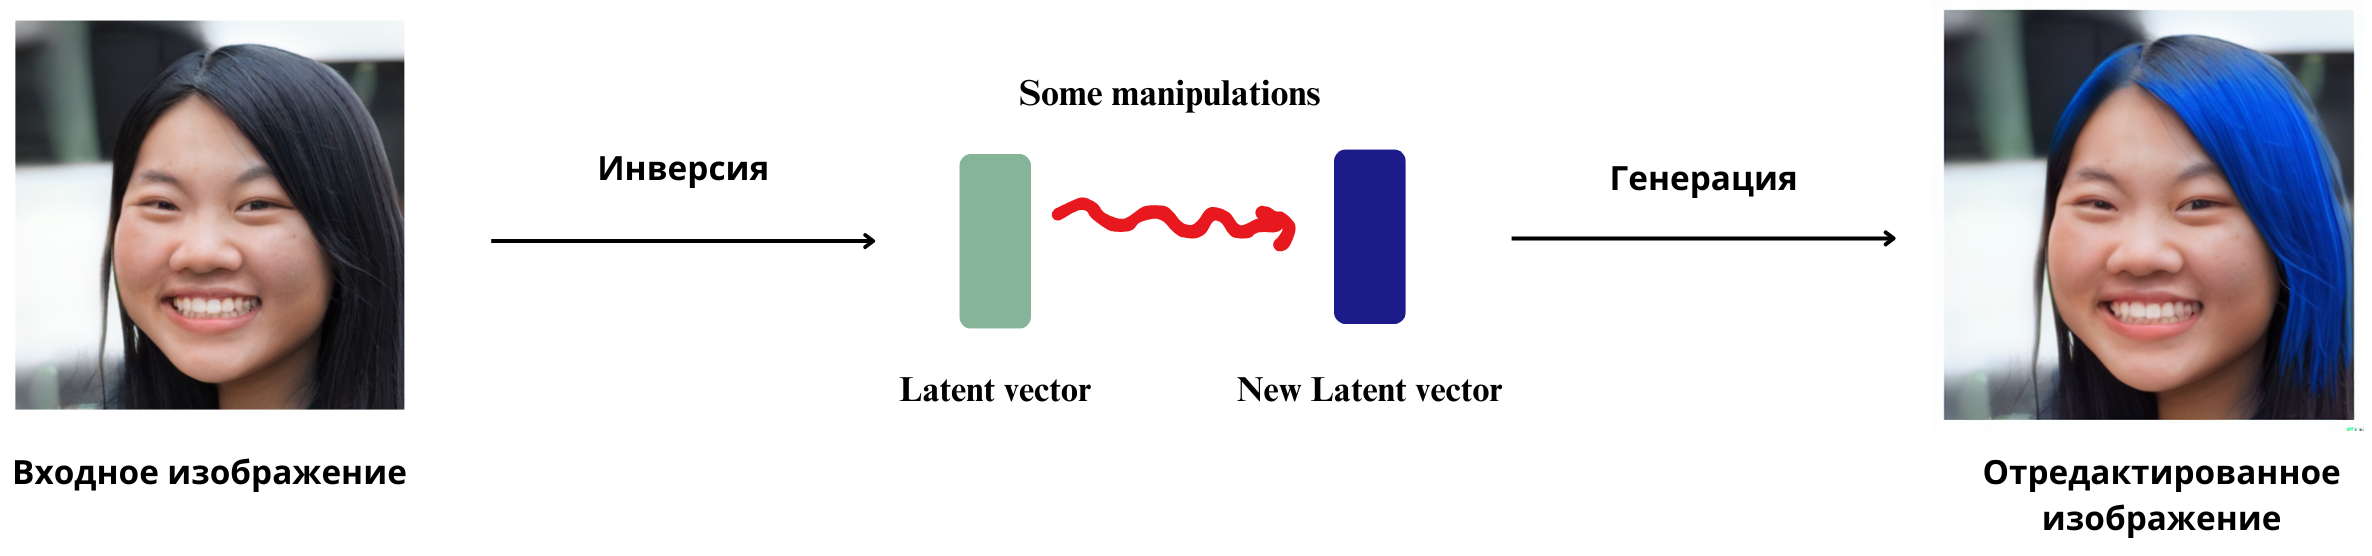

В данном семинаре мы не будем подробно останавливаться на задаче редактирования, а подробно рассмотрим задачу инверсии. Наш семинар будет состоять из нескольких основных частей:

1. Инверсия с помощью оптимизации в z-пространтсве

2. Инверсия с помощью оптимизации в w-пространстве

3. Инверсия с помощью оптимизации в w+-пространстве

4. Возможность использования энкодеров для данной задачи

5. Небольшой пример на редактирование и интерполяцию между латентами (ну а зачем это все?)


## Some additional installations and downloads

Для начала проведём некоторую вспомогательную работу и подгрузим все необходимые материалы.

In [ ]:
# Подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Клонирование репозитория StyleGAN2
!git clone https://github.com/rosinality/stylegan2-pytorch.git

In [ ]:
cd stylegan2-pytorch

In [ ]:
# Установка дополнительных библиотек
!pip install Ninja

In [ ]:
# Импорт необходимых библиотек
from google.colab import drive
import torch
import torch.optim as optim
from model import Generator
from torchvision.utils import save_image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch.optim as optim
import math  # Модуль для математических операций
import os  # Модуль для взаимодействия с операционной системой
from torch.nn import functional as F
from torchvision import transforms  # Модуль для преобразования изображений
from PIL import Image  # Библиотека для работы с изображениями
from tqdm import tqdm

In [ ]:
# Будем работать с конкретным сидом
torch.manual_seed(42)


Репозиторий StyleGAN-2 использует более старую версию библиотеки `skimage`, поэтому нам необходимо сделать небольшую корректировку файла с `lpips` лоссом.


In [ ]:
file_path = "/content/stylegan2-pytorch/lpips/__init__.py"

# Откроем файл и прочитаем его содержимое
with open(file_path, 'r') as file:
    lines = file.readlines()

# Заменим нужную строку
with open(file_path, 'w') as file:
    for line in lines:
        # Если в строке есть "compare_ssim", заменим на "structural_similarity"
        if "from skimage.measure import compare_ssim" in line:
            file.write("from skimage.metrics import structural_similarity\n")
        else:
            file.write(line)

print("Замена выполнена успешно!")

import lpips  # Библиотека для вычисления perceptual loss


In [ ]:
# Зададим девайс: cuda или cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Для работы со StyleGAN-2 нам для начала нужно скачать модель.  Для скачивания мы используем следующий код ниже. Веса скачаются в вашу папку.


In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# downloads StyleGAN's weights and facial recognition network weights
ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

## StyleGAN

**[StyleGAN2](https://arxiv.org/abs/1912.04958)** - это мощная модель генерации изображений, которая позволяет создавать реалистичные и разнообразные изображения.


Основная идея, отличающая **StyleGAN** от предыдущих архитектур (см. рис. (a) - Traditional) -- в использовании двух сеток вместо одной:




1. **Mapping Network**: Вместо прямого использования случайного латентного вектора $z$ для генерации изображения, StyleGAN2 преобразует $z$ в вектор $w$, которое также называется вектором пространством стиля  с помощью **Mapping network**. Обратите внимание, что она никак не меняет размерность $z$:

$$z (1 \times 512) → w (1 \times 512)$$

2. Далее у нас есть **Synthesis network** $g$, которая и будет генерировать нам изображение. Она состоит из различных блоков, в каждый из которых с помощью специальных модуляций будет подаваться вектор $w$ пропущенный через некоторые афинные трансформации $A$. Обратите внимание, что также после каждого из блоков дополнительно подаётся некоторый gaussian noise.


Основное отличие именно StyleGAN-2 -- использование модуляций вместо AdaIN слоёв (см. рис. (b) и (c)).

Более подробно про StyleGAN можно посмотреть в нашей лекции.

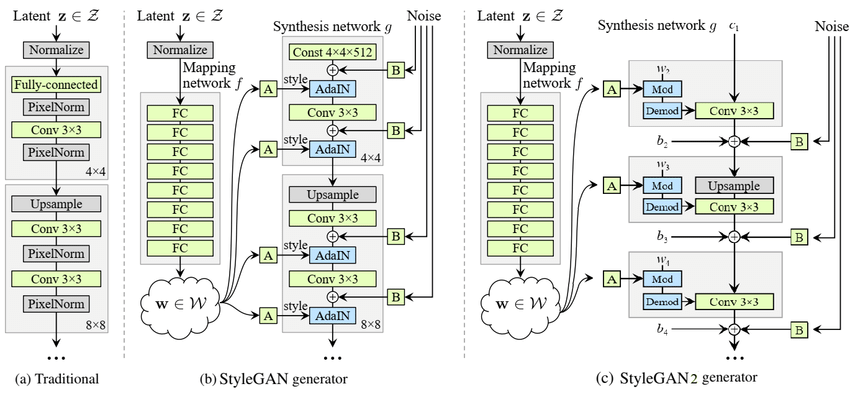

Давайте подгрузим наш генератор и посмотрим, как он генерирует изображения.

In [ ]:
# Параметры генератора
size = 1024  # Размер изображения
latent_dim = 512  # Размер латентного пространства
n_mlp = 8  # Количество слоев MLP
channel_multiplier = 2
ckpt = '/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt'  # Путь к весам StyleGAN2

In [ ]:
# Инициализация генератора
generator = Generator(size, latent_dim, n_mlp, channel_multiplier=channel_multiplier).to(device)
generator.eval()  # Режим валидации
checkpoint = torch.load(ckpt)
generator.load_state_dict(checkpoint["g_ema"])  # Подгрузка весов


### Несколько тестов генерации

In [ ]:
# Примеры генерации изображений
num_examples = 5  # Количество примеров для генерации

for i in range(num_examples):
    # Генерация случайного латентного вектора
    latent_z_example = torch.randn((1, latent_dim), device=device)
    generated_img_example, _ = generator([latent_z_example], input_is_latent=False)

    # Визуализация сгенерированного изображения
    plt.imshow((generated_img_example.clip(-1,1).cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
    plt.title(f"Сгенерированное изображение {i + 1}")
    plt.axis('off')
    plt.show()

## Инверсия


Как уже было отмечено, инверсия -- это преобразование изображения обратно в латентное пространство.

Зачем нам вообще инверсия? На самом деле, GANs модели могут иметь довольно "распутанное" внутреннее представление. Это значит, что с помощью несложных манипуляций с латентным пространством можно делать некоторые изменения, интерполяцию и другое над изображениями. Поэтому нам важно уметь из реального изображения получать эти самые латенты, чтобы проводить над ними манипуляции.



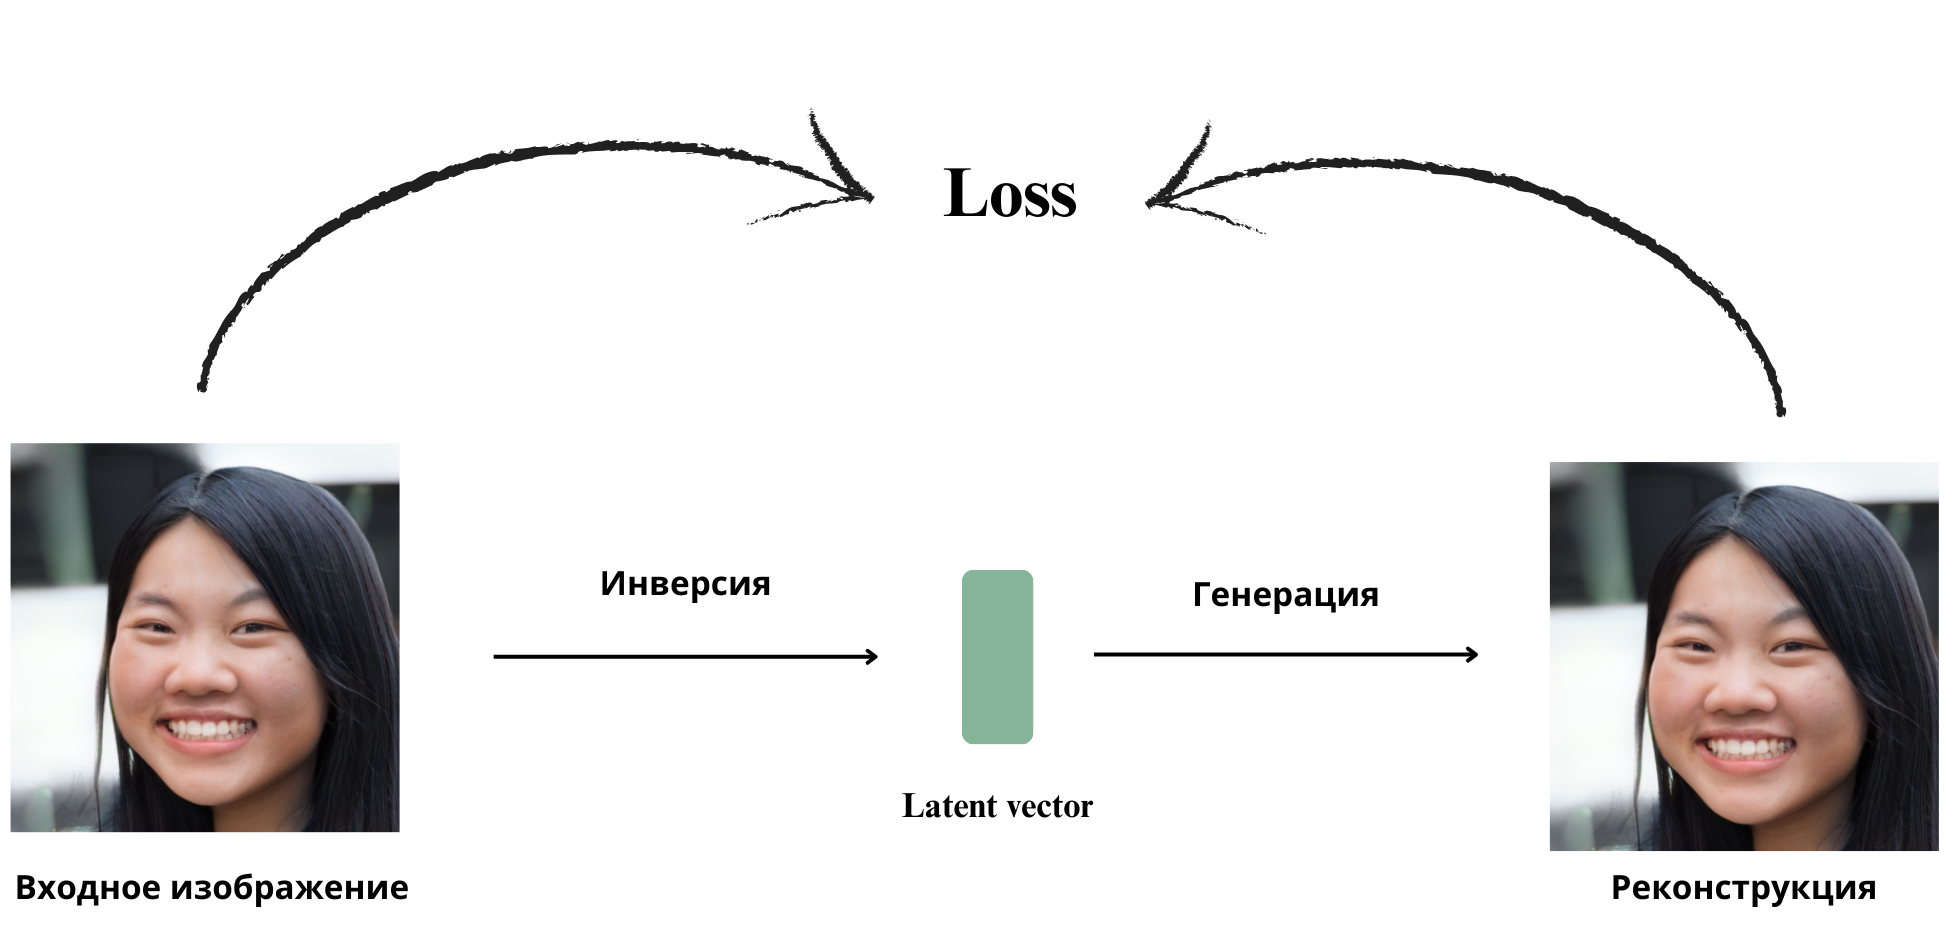

В этом семинаре мы попробуем несколько подходов для инверсии изображения:

- Оптимизация в $z$ пространстве.

- Оптимизация в $w$ пространстве.

- Специально обученные энкодеры.

## Инверсия в пространстве $z$

А начнём мы с инверсии в пространстве $z$. Алгоритм будет заключаться в следующем:

1. Инициализируем случайным вектором наш латентный вектор $z$

2. Генерируем с помощью генератора изображение из этого вектора и сравниваем с исходным - считаем MSE loss.

3. Делаем оптимизационный шаг в сторону уменьшения лосса.

4. Повторяем пока не сойдётся.

### Сгенерированное изображение

Начнём с инверсии сгенерированного изображения. Для этого просто засэмплируем случайный вектор, прогонем его через StyleGAN2 и получим картинку, с которой дальше будем работать.

In [ ]:
%matplotlib inline

In [ ]:
# Выбор целевого изображения: используйте либо загруженное, либо сгенерированное изображение

# Случай: Сгенерированное изображение
latent_z = torch.randn(10000, 512, device=device) # Z noise - засэмплируем множество векторов и возьмём средний
latent_z_generated = latent_z.mean(0, keepdim=True)
generated_img, _ = generator([latent_z_generated], input_is_latent=False)
save_image(generated_img, "generated_image.png")
target_img_tensor = generated_img.detach()  # Сохраняем изображение как целевое для инверсии

# Визуализируем нашу картинку. Дополнительно переводим изображение из [-1, 1] -> [0, 1], предварительно отрезав значения больше 1 и меньше -1
plt.imshow((generated_img.cpu().detach()[0].permute(1,2,0).clip(-1, 1) + 1)/2)
plt.show()

### Инверсия в пространстве Z

Начнём мы с простой функции потерь - MSE loss.

In [ ]:
# Инверсия в Z-пространстве
# Инициализация случайного вектора z и настройка оптимизатора и функции потерь
latent_z = torch.randn((1, latent_dim), device=device, requires_grad=True)  # Случайный вектор латентного пространства
optimizer_z = optim.Adam([latent_z], lr=1)  # Оптимизатор для инверсии в Z-пространстве
scheduler_z = torch.optim.lr_scheduler.ExponentialLR(optimizer_z, gamma=0.99)  # Скедулер

# Функция потерь
mse_loss = torch.nn.MSELoss()

# Оптимизация в Z-пространстве
num_steps = 500  # Количество шагов оптимизации
losses = []

for step in range(num_steps):

    optimizer_z.zero_grad()  # Обнуление градиентов перед новой итерацией

    # Генерация изображения из текущего вектора z
    generated_img, _ = generator([latent_z], input_is_latent=False)

    # Вычисление MSE между сгенерированным и целевым изображением
    loss = mse_loss(generated_img, target_img_tensor)
    loss.backward()
    optimizer_z.step()  # Обновление латентного вектора
    scheduler_z.step(loss)
    losses.append(loss.item())

    torch.cuda.empty_cache()  # Очистка кеша CUDA для освобождения памяти

    if step % 100 == 0:  # Каждые 50 шагов
        print(f"inversion_generated_z/Step [{step}/{num_steps}], Loss: {loss.item():.4f}")  # Вывод текущего лосса
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")
        axs[0].axis('off')  # Отключение осей

        # Визуализация исходного изображения
        axs[1].imshow((target_img_tensor.cpu().detach()[0].permute(1, 2, 0).clip(-1,1) + 1) / 2)
        axs[1].set_title("Исходное изображение")
        axs[1].axis('off')  # Отключение осей

        plt.show()

print("Инверсия в Z-пространстве завершена.")

In [ ]:
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses)
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow((generated_img.cpu().detach().squeeze().permute(1, 2, 0) + 1) / 2)
axs[0].set_title("Сгенерированное изображение")
axs[0].axis('off')

axs[1].imshow((target_img_tensor.cpu().squeeze().permute(1, 2, 0).clip(-1,1) + 1) / 2)
axs[1].set_title("Целевое изображение")
axs[1].axis('off')

plt.show()


Давайте сохраним результаты: оптимизированный латентный вектор и изображение, полученное из него.

In [ ]:
save_dir = 'optimization_results'
filename = "z_optimization_mse"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
torch.save(latent_z, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(generated_img, image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")



### Результат

Как мы видим - результаты выглядят довольно сомнительно :)

Давайте попробуем улучшить качество с помощью улучшения loss функции. Для этого воспользуемся lpips функцией. LPIPS (Learned Perceptual Image Patch Similarity) — это такая метрика (лосс), которая использует предобученную нейронную сеть для оценки сходства изображений. Считается, что LPIPS очень хорошо коррелирует с человеческим восприятием.

### Улучшение с помощью perceptual

Добавим `perceptual_loss` на основе `alexnet` (в качестве эксперимента можете попробовать использовать другую модель, например `vgg`).


In [ ]:
# Загрузка Perceptual Loss (LPIPS)
perceptual_loss = lpips.PerceptualLoss(
      model="net-lin", net="alex", use_gpu=device
  )
print("LPIPS загружен.")
print("Генератор успешно загружен.")

In [ ]:
# Инверсия в Z-пространстве
# Инициализация случайного вектора z и настройка оптимизатора и функции потерь
latent_z = torch.randn((1, latent_dim), device=device, requires_grad=True)  # Случайный вектор латентного пространства
optimizer_z = optim.Adam([latent_z], lr=0.1)  # Оптимизатор для инверсии в Z-пространстве
scheduler_z = torch.optim.lr_scheduler.ExponentialLR(optimizer_z, gamma=0.99)

# Функция потерь MSE
mse = torch.nn.MSELoss()

# Оптимизация в Z-пространстве
num_steps = 500  # Количество шагов оптимизации
alpha = 1  # Коэффициент для LPIPS

losses = {
    "mse": [],
    "lpips": [],
    "all": []
}


for step in range(num_steps):

    torch.cuda.empty_cache()
    optimizer_z.zero_grad()  # Обнуление градиентов перед новой итерацией
    # Генерация изображения из текущего вектора z
    generated_img, _ = generator([latent_z], input_is_latent=False)

    # Вычисление MSE между сгенерированным и исходным изображением
    mse_loss = mse(generated_img, target_img_tensor)  # Вычисление потерь MSE
    lpips_loss = perceptual_loss(generated_img, target_img_tensor).mean()  # Вычисление LPIPS loss
    loss = mse_loss + alpha * lpips_loss  # Общий лосс

    loss.backward()
    optimizer_z.step()  # Обновление параметров латентного вектора
    scheduler_z.step(loss)

    torch.cuda.empty_cache()  # Очистка кеша CUDA для освобождения памяти

    # Сохраним наши лоссы для визуализации
    losses['mse'].append(mse_loss.item())
    losses['lpips'].append(lpips_loss.item())
    losses['all'].append(loss.item())
    if step % 100 == 0:  # Каждые 50 шагов
        print(f"inversion_generated_z/Step [{step}/{num_steps}], Loss: {loss.item():.4f}")  # Вывод текущего лосса
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].permute(1, 2, 0).clip(-1,1) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")
        axs[0].axis('off')  # Отключение осей

        # Визуализация исходного изображения
        axs[1].imshow((target_img_tensor.cpu().detach()[0].permute(1, 2, 0).clip(-1,1) + 1) / 2)
        axs[1].set_title("Целевое изображение")
        axs[1].axis('off')

        plt.show()  # Отображение графиков

print("Инверсия в Z-пространстве завершена.")

In [ ]:
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses['all'], label='Summ')
plt.plot(losses['lpips'], label='LPIPS')
plt.plot(losses['mse'], label='MSE')
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow((generated_img.cpu().detach().squeeze().permute(1, 2, 0) + 1) / 2)
axs[0].set_title("Сгенерированное изображение")
axs[0].axis('off')

axs[1].imshow((target_img_tensor.cpu().squeeze().permute(1, 2, 0).clip(-1,1) + 1) / 2)
axs[1].set_title("Целевое изображение")
axs[1].axis('off')

plt.show()


In [ ]:
# Сохранение результатов

save_dir = 'optimization_results'
filename = "z_optimization_mse_lpips"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
torch.save(latent_z, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(generated_img, image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")



Выглядит неплохо! Гораздо лучше, чем при оптимизации MSE loss :)

Вы можете самостоятельно попробовать "покрутить" коэффициент $\alpha$ в функции потерь для того, чтобы понять, как влияет большой коэффициент при MSE и LPIPS loss функции. Давайте попробуем теперь попробуем инвертировать реальную картинку.

### Инверсия реального изображения

Мы с вами разобрали пример инверсии сгенерированного изображения. Давайте теперь попробуем ту же самую оптимизацию, но с реальными картинками. Для этого необходимо подгрузить папку с изображениями (есть на гугл диске там же, где и этот ноутбук)

In [ ]:
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Загрузка и подготовка реального изображения
# Укажите путь к изображению
real_image_path = '/content/images/00001.png'

target_img = Image.open(real_image_path).convert('RGB')

# Некоторая трансформация: кроп изображения для получения квадратной картинки и ресайз в нужное разрешение
transform = transforms.Compose([
    transforms.CenterCrop(min(target_img.size)),
    transforms.Resize((1024, 1024))
])


target_img = transform(target_img)

target_img_tensor = torch.tensor(np.array(target_img).transpose(2, 0, 1)).float().to(device) / 255.
target_img_tensor = target_img_tensor.unsqueeze(0)* 2 - 1 # Добавление размерности batch и [0, 1] -> [-1, 1]

print("Реальное изображение загружено и подготовлено.")

# Визуализация изображения
plt.imshow((target_img_tensor.cpu()[0].permute(1, 2, 0) + 1)/2)

plt.show()

### Выравнивание (alighnemnt)

StyleGAN2, с которым мы работаем, обучался на датасете FFHQ, где лица были выровнены перед обучением. Это значит, что они находятся в определённом положении. Поэтому, если мы попытаемся инвертировать невыравненное лицо - наш генератор не сделает это качественно, так как в пространстве выученных изображений такого нет. Существую различные подходы, как это делать, мы не будем останавливаться подробно. Часто это делается по каким-то ключевым точкам на лице, например, как это показано на [изображении](https://www.researchgate.net/figure/A-face-image-alignment-example-The-original-image-is-shown-in-a-b-shows-the-68_fig4_280538390) ниже. Если вам будет интересно, можете подробнее изучить библиотеку [dlib](http://dlib.net/).

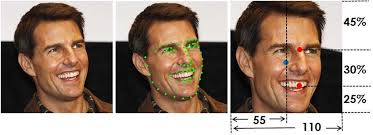

Мы для примера взяли изображение из датасета ffhq, которое уже заалайнено и находится в нужной позе. В случае случайного изображения необходимо проделать дополнительный алаймент и мы обсудим это в блоке про энкодер для инверсии.

In [ ]:
# Инверсия в Z-пространстве
# Инициализация случайного вектора z и настройка оптимизатора и функции потерь
latent_z = torch.randn((1, latent_dim), device=device, requires_grad=True)  # Случайный вектор латентного пространства
optimizer_z = optim.Adam([latent_z], lr=0.1)  # Оптимизатор для инверсии в Z-пространстве
scheduler_z = torch.optim.lr_scheduler.ExponentialLR(optimizer_z, gamma=0.99)

# Функция потерь
mse = torch.nn.MSELoss()

# Оптимизация в Z-пространстве
num_steps = 500  # Количество шагов оптимизации
alpha = 1  # Коэффициент для LPIPS
losses = {
    "mse": [],
    "lpips": [],
    "all": []
}


for step in range(num_steps):

    torch.cuda.empty_cache()
    optimizer_z.zero_grad()  # Обнуление градиентов перед новой итерацией
    # Генерация изображения из текущего вектора z
    generated_img, _ = generator([latent_z], input_is_latent=False)

    # Вычисление MSE между сгенерированным и исходным изображением
    mse_loss = mse(generated_img, target_img_tensor)  # Вычисление MSE
    lpips_loss = perceptual_loss(generated_img, target_img_tensor).mean()  # Вычисление LPIPS
    loss = mse_loss + alpha * lpips_loss  # Общий лосс

    loss.backward()
    optimizer_z.step()  # Обновление параметров латентного вектора
    scheduler_z.step(loss)

    # Сохраним наши лоссы для визуализации
    losses['mse'].append(mse_loss.item())
    losses['lpips'].append(lpips_loss.item())
    losses['all'].append(loss.item())
    if step % 100 == 0:  # Каждые 50 шагов
        print(f"inversion_generated_z/Step [{step}/{num_steps}], Loss: {loss.item():.4f}")  # Вывод текущего лосса
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].permute(1, 2, 0).clip(-1,1) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")
        axs[0].axis('off')

        # Визуализация исходного изображения
        axs[1].imshow((target_img_tensor.cpu().detach()[0].permute(1, 2, 0).clip(-1,1) + 1) / 2)
        axs[1].set_title("Исходное изображение")
        axs[1].axis('off')

        plt.show()
print("Инверсия в Z-пространстве завершена.")

In [ ]:
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses['all'], label='Summ')
plt.plot(losses['lpips'], label='LPIPS')
plt.plot(losses['mse'], label='MSE')
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow((generated_img.cpu().detach().squeeze().permute(1, 2, 0) + 1) / 2)
axs[0].set_title("Сгенерированное изображение")
axs[0].axis('off')

axs[1].imshow((target_img_tensor.cpu().squeeze().permute(1, 2, 0).clip(-1,1) + 1) / 2)
axs[1].set_title("Целевое изображение")
axs[1].axis('off')

plt.show()


In [ ]:
# Сохранение результатов

save_dir = 'optimization_results'
filename = "real_image_z_optimization_mse_lpips"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
torch.save(latent_z, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(generated_img, image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")


Почему же так происходит? Почему реальное изображение не так красиво инвертируется? Результат чуть более замылен и могут теряться детали (например серьги, не совсем такие как нужно зубы и так далее). На самом деле есть два основных момента:

1. Когда мы учим распрделение реальных изображений с помощью GAN - мы на самом деле не выучиваем всё пространство изображений одинаково хорошо. Поэтому мы можем инвертировать нашу картинку в тот кусок латентного пространства с которым генератор не умеет так хорошо работать.
2. Инверсия mapping network сама по себе непростая, поэтому хорошо бы избежать данной инверсии.

Для решения этой проблемы мы с вами попробуем инвертировать картинку не в $Z$-пространство, а в $W$ и $W+$-постранство.

### Инверсия в пространстве W

In [ ]:
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Загрузка и подготовка реального изображения
# Укажите путь к изображению
real_image_path = '/content/images/00001.png'

target_img = Image.open(real_image_path).convert('RGB')

# Некоторая трансформация: кроп изображения для получения квадратной картинки и ресайз в нужное разрешение
transform = transforms.Compose([
    transforms.CenterCrop(min(target_img.size)),
    transforms.Resize((1024, 1024))
])


target_img = transform(target_img)

target_img_tensor = torch.tensor(np.array(target_img).transpose(2, 0, 1)).float().to(device) / 255.
target_img_tensor = target_img_tensor.unsqueeze(0)* 2 - 1 # Добавление размерности batch и [0, 1] -> [-1, 1]

print("Реальное изображение загружено и подготовлено.")

# Визуализация изображения
plt.imshow((target_img_tensor.cpu()[0].permute(1, 2, 0) + 1)/2)

plt.show()

Как уже было сказано, инверсия **mapping network** сама по себе довольно неочевидная. Давайте попробуем провести инверсию в пространстве вектора $w$.

Авторы StyleGAN-2 предлагают некоторый усовешенствованный процесс инвертирования модели.

*   Во-первых, они добавляют немного шума в оптимизируемые латенты для большего исследования латентного пространства
*   Во-вторых, авторы дополнительно оптмизируют шумы (noises), которые добавляются в генератор (см. изображение ниже). Авторы дополнительно ацентируют внимание на том, что необходимо наложить дополнительную регуляризацию на эти шумы, так как они не должны содержать какой-то сигнла из исходного изображения.




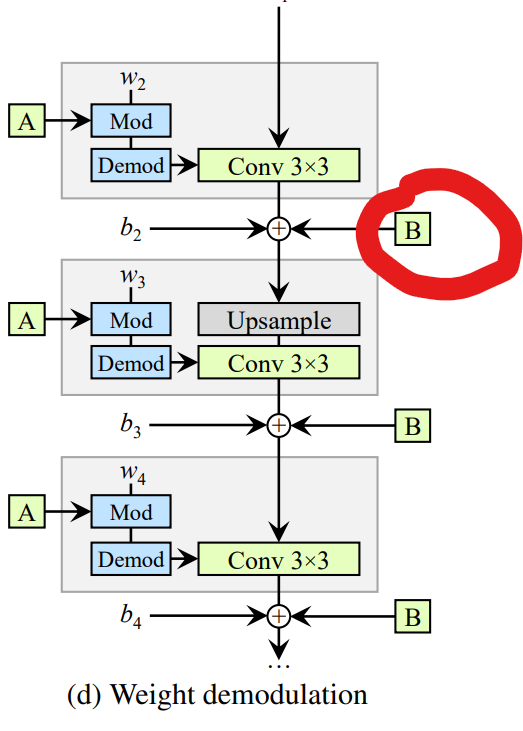

Давайте разберёмся как построить эту регуляризацию. Авторы берут все noise maps, разрешение которых больше $8 \times 8$ и downsample их в меньшие разрешения (до $8 \times 8$) путём усреднения соседей в $2 \times 2$ областях.


Пусть у нас есть карта шума $n_{i, 0} = n_i$ c разрешением $r_{i, 0}$. Тогда downsampled шум - $n_{i, j>0}$ с разрешением $r_{i, j>0}$ и $r_{i, j+1} = r_{i, j}/2$.

Финальный лосс можно записать следующим образом.

$$L_{i,j} = \left( \frac{1}{r_{i,j}^2} \sum_{x,y} n_{i,j}(x, y) \cdot n_{i,j}(x - 1, y) \right)^2 + \left( \frac{1}{r_{i,j}^2} \sum_{x,y} n_{i,j}(x, y) \cdot n_{i,j}(x, y - 1) \right)^2$$

Основная идея этого регуляризационного лосса в том, чтобы минимизировать автокорреляцию карт шума (noise maps) на один пиксель по горизонтали и вертикали. Если шум имеет нормальное распределение, автокорреляция должна стремиться к нулю, так как значение шума в каждой точке не должно быть связано с соседями.


Дополнительно воспользуемся специальным скедулером для lr:




In [ ]:

def get_lr(t, initial_lr, rampdown=0.25, rampup=0.05):
    lr_ramp = min(1, (1 - t) / rampdown)
    lr_ramp = 0.5 - 0.5 * math.cos(lr_ramp * math.pi)
    lr_ramp = lr_ramp * min(1, t / rampup)

    return initial_lr * lr_ramp

Нарисуем как он выглядит для шагов от до до $T=1000$ при изначальом значении $\text{initial_lr}=0.25$.

In [ ]:
lr_steps = []
for step in range(1000):
    torch.cuda.empty_cache()
    t = step / 1000
    lr = get_lr(t, 0.25)
    lr_steps.append(lr)

plt.plot(lr_steps)
plt.title('lr vs step')
plt.show()

Сначала подготовим несколько вспомогательных функций для работы с шумами (gaussian nosises) в styleGAN-2

In [ ]:
def noise_regularize(noises):
    """
    Функция для регуляризации шума.
    Вычисляет лосс на основе шума, чтобы уменьшить его влияние на генерацию.

    Параметры:
    noises (list): Список тензоров шума.

    Возвращает:
    loss (float): Общая потеря, связанная с шумом.
    """
    loss = 0  # Инициализация потерь

    for noise in noises:  # Проход по каждому шуму в списке
        size = noise.shape[2]

        while True:  # Цикл для уменьшения размера шума
            # Вычисление лосса на основе свертки шума с его сдвинутой версией
            loss = (
                loss
                + (noise * torch.roll(noise, shifts=1, dims=3)).mean().pow(2)  # Сдвиг по ширине
                + (noise * torch.roll(noise, shifts=1, dims=2)).mean().pow(2)  # Сдвиг по высоте
            )

            if size <= 8:
                break

            # Уменьшение размера шума вдвое
            noise = noise.reshape([-1, 1, size // 2, 2, size // 2, 2])
            noise = noise.mean([3, 5])
            size //= 2

    return loss


def noise_normalize_(noises):
    """
    Нормализация шума.
    Приводит шум к нулевому среднему и единичной дисперсии.

    Параметры:
    noises (list): Список тензоров шума.
    """
    for noise in noises:
        mean = noise.mean()  # Вычисление среднего значения
        std = noise.std()  # Вычисление стандартного отклонения

        # Нормализация: вычитание среднего и деление на стандартное отклонение
        noise.data.add_(-mean).div_(std)


def latent_noise(latent, strength):
    """
    Добавление шума к латентному вектору.
    Генерирует случайный шум и добавляет его к латентному вектору.

    Параметры:
    latent (Tensor): Латентный вектор.
    strength (float): Сила добавляемого шума.

    Возвращает:
    Tensor: Латентный вектор с добавленным шумом.
    """
    noise = torch.randn_like(latent) * strength

    return latent + noise

Посмотрим на наш стилевой вектор

In [ ]:
# Преобразуем оптимизированный Z-вектор в W-пространство
latent_z = torch.randn(10000, 512, device=device).mean(0, keepdim=True) # Z noise
latent_w = generator.style(latent_z) # Преобразование Z-вектора в W-вектор
latent_mean = latent_w.mean(0)
latent_std = ((latent_w - latent_mean).pow(2).sum() / 10000) ** 0.5
print(latent_z.mean(0).shape, latent_mean.shape)


In [ ]:
noises_single = generator.make_noise()
noises = []
for noise in noises_single:
    noises.append(noise.repeat(1, 1, 1, 1).normal_())

In [ ]:
# Функция потерь MSE
mse = torch.nn.MSELoss()

w_plus = False

num_steps_w = 500  # Количество шагов оптимизации в W-пространстве
alpha = 5  # Коэффициент для перцептивной потери
beta = 1e5

latent_in = latent_mean.detach().clone().unsqueeze(0).repeat(1, 1)

if w_plus:
  latent_in = latent_in.unsqueeze(1).repeat(1, generator.n_latent, 1)

latent_in.requires_grad = True

for noise in noises:
    noise.requires_grad = True

optimizer_w = optim.Adam([latent_in] + noises, lr=0.25)  # Оптимизатор для инверсии в W-пространстве
# scheduler_w = torch.optim.lr_scheduler.ExponentialLR(optimizer_w, gamma=0.99)  # Плавное снижение скорости обучения


losses = {
    'mse': [],
    'lpips': [],
    'noise_reg': [],
    'all': []
}
init_lr = 0.25

# Инверсия в W-пространстве с шумовой регуляризацией
for step in range(num_steps_w):
    torch.cuda.empty_cache()
    t = step / num_steps_w
    lr = get_lr(t, init_lr)
    optimizer_w.param_groups[0]["lr"] = lr
    optimizer_w.zero_grad()  # Обнуление градиентов перед новой итерацией

    noise_strength = latent_std * 0.05 * max(0, 1 - t / 0.75) ** 2
    latent_n = latent_noise(latent_in, noise_strength.item())

    generated_img, _ = generator([latent_n], input_is_latent=True, noise=noises)  # Генерация изображения из W-вектора

    # Основные потери
    noise_loss = noise_regularize(noises)
    mse_loss = mse(generated_img, target_img_tensor)  # Вычисление потерь MSE
    lpips_loss = perceptual_loss(generated_img, target_img_tensor).mean()  # Вычисление перцептивной потери
    # noise_reg_loss = noise_regularize(noises) * noise_strength  # (опционально) Шумовая регуляризация

    # Суммарные потери
    loss = mse_loss + alpha * lpips_loss + beta * noise_loss # Общая потеря: сумма MSE и перцептивной потери с учетом коэффициента alpha
    loss.backward()  # Обратное распространение ошибки

    optimizer_w.step()  # Обновление параметров W-вектора
    noise_normalize_(noises)

    losses['mse'].append(mse_loss.item())
    losses['lpips'].append(lpips_loss.item())
    losses['noise_reg'].append(noise_loss.item())
    losses['all'].append(loss.item())

    if step % 50 == 0:  # Каждые 50 шагов
        print(f"inversion_generated_w/Step [{step}/{num_steps_w}], Loss: {loss.item():.4f}")  # Вывод текущих потерь
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")  # Заголовок для сгенерированного изображения
        axs[0].axis('off')  # Отключение осей

        # Визуализация целевого изображения
        axs[1].imshow((target_img_tensor.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[1].set_title("Целевое изображение")  # Заголовок для целевого изображения
        axs[1].axis('off')  # Отключение осей

        plt.show()  # Отображение графиков
        save_image(generated_img, f"z_inversion_step_{step}.png")  # Сохранение сгенерированного изображения

print("Инверсия в W-пространстве с регуляризацией шумов завершена.")  # Сообщение о завершении процесса

In [ ]:
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses['all'], label='Summ')
plt.plot(losses['lpips'], label='LPIPS')
plt.plot(losses['mse'], label='MSE')
plt.plot(losses['noise_reg'], label='Noise')
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses['lpips'], label='LPIPS')
plt.plot(losses['mse'], label='MSE')
#plt.plot(losses['noise_reg'], label='Noise')
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow((generated_img.cpu().detach().squeeze().permute(1, 2, 0) + 1) / 2)
axs[0].set_title("Сгенерированное изображение")
axs[0].axis('off')

axs[1].imshow((target_img_tensor.cpu().squeeze().permute(1, 2, 0).clip(-1,1) + 1) / 2)
axs[1].set_title("Целевое изображение")
axs[1].axis('off')

plt.show()


In [ ]:
# Сохранение результатов

save_dir = 'optimization_results'
filename = "real_image_w_optimization"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
print(f"Оптимизированные латенты имеют размерность: {latent_in.shape}")
torch.save(latent_in, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(generated_img, image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")


Как мы видим, результат стал получше. По крайней мере зубы тепеь более четко соответсвуют оригиналу, появилось больше сходств кожи лица. Однако все ещё неидеальный результат, в частности, например, не хватает сережки.

### Попробуем с пространством $W+$

In [ ]:
# Преобразуем оптимизированный Z-вектор в W-пространство
latent_z = torch.randn(10000, 512, device=device).mean(0, keepdim=True) # Z noise
latent_w = generator.style(latent_z) # Преобразование Z-вектора в W-вектор
latent_mean = latent_w.mean(0)
latent_std = ((latent_w - latent_mean).pow(2).sum() / 10000) ** 0.5
print(latent_z.mean(0).shape, latent_mean.shape)
noises_single = generator.make_noise()
noises = []
for noise in noises_single:
    noises.append(noise.repeat(1, 1, 1, 1).normal_())

In [ ]:
generator.n_latent

In [ ]:
# Функция потерь MSE
mse = torch.nn.MSELoss()

w_plus = True

num_steps_w = 1000  # Количество шагов оптимизации в W-пространстве
alpha = 5  # Коэффициент для перцептивной потери
beta = 1e5

latent_in = latent_mean.detach().clone().unsqueeze(0).repeat(1, 1)

if w_plus:
  latent_in = latent_in.unsqueeze(1).repeat(1, generator.n_latent, 1)

latent_in.requires_grad = True

for noise in noises:
    noise.requires_grad = True

optimizer_w = optim.Adam([latent_in] + noises, lr=0.25)  # Оптимизатор для инверсии в W-пространстве
# scheduler_w = torch.optim.lr_scheduler.ExponentialLR(optimizer_w, gamma=0.99)  # Плавное снижение скорости обучения


losses = {
    'mse': [],
    'lpips': [],
    'noise_reg': [],
    'all': []
}
init_lr = 0.25

# Инверсия в W-пространстве с шумовой регуляризацией
for step in range(num_steps_w):
    torch.cuda.empty_cache()
    t = step / num_steps_w
    lr = get_lr(t, init_lr)
    optimizer_w.param_groups[0]["lr"] = lr
    optimizer_w.zero_grad()  # Обнуление градиентов перед новой итерацией

    noise_strength = latent_std * 0.05 * max(0, 1 - t / 0.75) ** 2
    latent_n = latent_noise(latent_in, noise_strength.item())

    generated_img, _ = generator([latent_n], input_is_latent=True, noise=noises)  # Генерация изображения из W-вектора

    # Основные потери
    noise_loss = noise_regularize(noises)
    mse_loss = mse(generated_img, target_img_tensor)  # Вычисление потерь MSE
    lpips_loss = perceptual_loss(generated_img, target_img_tensor).mean()  # Вычисление перцептивной потери
    # noise_reg_loss = noise_regularize(noises) * noise_strength  # (опционально) Шумовая регуляризация

    # Суммарные потери
    loss = mse_loss + alpha * lpips_loss + beta * noise_loss # Общая потеря: сумма MSE и перцептивной потери с учетом коэффициента alpha
    loss.backward()  # Обратное распространение ошибки

    optimizer_w.step()  # Обновление параметров W-вектора

    noise_normalize_(noises)

    losses['mse'].append(mse_loss.item())
    losses['lpips'].append(lpips_loss.item())
    losses['noise_reg'].append(noise_loss.item())
    losses['all'].append(loss.item())

    if step % 50 == 0:  # Каждые 50 шагов
        print(f"inversion_generated_w/Step [{step}/{num_steps_w}], Loss: {loss.item():.4f}")  # Вывод текущих потерь
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")  # Заголовок для сгенерированного изображения
        axs[0].axis('off')  # Отключение осей

        # Визуализация целевого изображения
        axs[1].imshow((target_img_tensor.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[1].set_title("Целевое изображение")  # Заголовок для целевого изображения
        axs[1].axis('off')  # Отключение осей

        plt.show()  # Отображение графиков
        save_image(generated_img, f"z_inversion_step_{step}.png")  # Сохранение сгенерированного изображения

print("Инверсия в W-пространстве с регуляризацией шумов завершена.")  # Сообщение о завершении процесса

In [ ]:
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses['lpips'], label='LPIPS')
plt.plot(losses['mse'], label='MSE')
plt.plot(losses['noise_reg'], label='Noise')
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow((generated_img.cpu().detach().squeeze().permute(1, 2, 0) + 1) / 2)
axs[0].set_title("Сгенерированное изображение")
axs[0].axis('off')

axs[1].imshow((target_img_tensor.cpu().squeeze().permute(1, 2, 0).clip(-1,1) + 1) / 2)
axs[1].set_title("Целевое изображение")
axs[1].axis('off')

plt.show()


In [ ]:
# Сохранение результатов

save_dir = 'optimization_results'
filename = "real_image_w+_optimization"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
print(f"Оптимизированные латенты имеют размерность: {latent_in.shape}")
torch.save(latent_in, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(generated_img, image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")


Заметим, что в таком сценарии мы смогла даже выучить серьги и пальцы :)

## Предобученный энкодер


Способы для инверсии ганов обычно делять на два основных типа:

- optimization based

- encoder-based

Итак, мы посмотрели, как работает оптимизация. Один из важных недостатков оптимизации - это время.

В этом разделе мы попробуем посмотреть специально обученную модель из статьи "[Designing an Encoder for StyleGAN Image Manipulation](https://arxiv.org/abs/2102.02766). Основная идея этой работы в том, чтобы построить такой энкодер, который умеет инвертировать входное изображение в латент $w$, с которым мы и хотим проводить манипуляции. Мы не будем сейчас подробно останавливаться на том, как проводится обучение, для всех интересующихся можно почитать статью.

А мы попробуем запустить сам инференс модели.

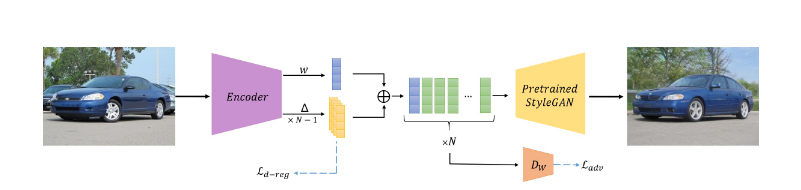

In [ ]:
cd ../

In [ ]:
! git clone https://github.com/omertov/encoder4editing.git

In [ ]:
cd encoder4editing

In [ ]:
# Импортируем необходимые библиотеки
from models.psp import pSp  # Импортируем модель pSp
from argparse import Namespace


Подгрузим нашу модель

In [ ]:
# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# downloads encoders's weights and facial recognition network weights
ids = ['1cUv_reLE6k3604or78EranS7XzuVMWeO']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

In [ ]:
# Определяем преобразования для изображения
transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Изменяем размер изображения до 256x256
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Нормализуем значения пикселей
])


In [ ]:
# Загружаем предобученную модель pSp
model_path = '/content/encoder4editing/e4e_ffhq_encode.pt'  # Путь к весам энкодера
ckpt = torch.load(model_path, map_location='cpu')
opts = ckpt['opts']

opts['checkpoint_path'] = model_path
opts = Namespace(**opts)
net = pSp(opts)
net.eval()
net.to(device)
print('Model successfully loaded!')


In [ ]:
# Загружаем и отображаем изображение
from PIL import Image
image_path = '/content/images/haus.jpeg'  # Путь к изображению
original_image = Image.open(image_path)
original_image = original_image.convert("RGB")  # Преобразуем изображение в RGB формат
original_image

## Aligning

Мы уже говорили про то, что StyleGAN обучался на лицах в определенной позиции. Поскольку мы сейчас работаем с реальным изображениме, его положение на картинке может быть не таким, как в датасете FFHQ. Именно для этого нам необходимо повернуть его в нужную позу для более качественной работы генератора.

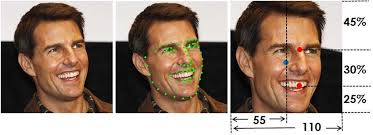

In [ ]:
# Определяем тип эксперимента
experiment_type = "ffhq_encode"

# Загружаем модель для определения ключевых точек лица - понадобится нам для выравнивания
if experiment_type == "ffhq_encode" and 'shape_predictor_68_face_landmarks.dat' not in os.listdir():
    !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2  # Скачиваем архив с моделью
    !bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2  # Распаковываем архив

# Задаем размер изображения для изменения
resize_dims = (256, 256)


def run_alignment(image_path):
  """Выравнивает лицо на изображении, используя dlib.

  Args:
      image_path: Путь к файлу изображения.

  Returns:
      Выровненное изображение в формате PIL.Image.
  """
  import dlib
  from utils.alignment import align_face  # Функция для выравнивания лица
  predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
  aligned_image = align_face(filepath=image_path, predictor=predictor)
  print("Aligned image has shape: {}".format(aligned_image.size))
  return aligned_image  # Возвращаем выровненное изображение

# Выравниваем лицо, если тип эксперимента - кодирование FFHQ
if experiment_type == "ffhq_encode":
  input_image = run_alignment(image_path)
else:
  input_image = original_image


input_image.resize(resize_dims)

In [ ]:
%matplotlib inline

In [ ]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(np.asarray(input_image))
axs[0].set_title("Исходное изображение")
axs[0].axis('off')

axs[1].imshow(np.asarray(original_image))
axs[1].set_title("Выровненное изображение")
axs[1].axis('off')

plt.show()


In [ ]:
transformed_image = transform(input_image)  # Применяем преобразования, определенные ранее

# Определяем функцию для отображения результата рядом с исходным
def display_alongside_source_image(result_image, source_image):
    """Отображает результат рядом с исходным изображением.

    Args:
        result_image: Результирующее изображение (PIL.Image).
        source_image: Исходное изображение (PIL.Image).

    Returns:
        Объединенное изображение (PIL.Image).
    """
    res = np.concatenate([np.array(source_image.resize(resize_dims)),
                          np.array(result_image.resize(resize_dims))], axis=1)
    return Image.fromarray(res)


def run_on_batch(inputs, net):
    """Запускает модель на пакете данных.

    Args:
        inputs: Входные данные (тензор PyTorch).
        net: Модель pSp.

    Returns:
        Сгенерированные изображения и латентные векторы.
    """
    images, latents = net(inputs.to("cuda").float(), randomize_noise=False, return_latents=True)  # Запускаем модель
    return images, latents


Посмотрим на пары реальное изображение - инвертированное

In [ ]:
# Запускаем модель и измеряем время выполнения
import time  # Модуль для работы со временем
from utils.common import tensor2im
import numpy as np

with torch.no_grad():
    tic = time.time()  # Время начала выполнения
    images, latents = run_on_batch(transformed_image.unsqueeze(0), net)
    result_image, latent = images[0], latents[0]  # Извлекаем результат и латентный вектор
    toc = time.time()  # Время окончания выполнения
    print('Inference took {:.4f} seconds.'.format(toc - tic))

# Отображаем результат инверсии
display_alongside_source_image(tensor2im(result_image), input_image)

## Бонус

В качестве бонуса мы посмотрим на

1. Эдитинг

2. Интерполяцию между двумя картинками.





### Эдитинг

Одно из приложений данной модели - использование её для различных манипуляций.

Оказывается, если сдвигаться в определённом направлении при работе с латентными векторами, то можно контролировать различные атрибуты, например возраст (young <-> old) или улыбку (smile <-> not smile). Авторы предлагают обучить как раз такое направление для модели, чтобы взять под контроль некоторые атрибуты (мы рассмотрим улыбку, позу и возраст).

К сожалению, время на семинаре весьма ограничено, но вы можете подробнее почитать [в статье](https://arxiv.org/pdf/2102.02766), как именно обучать подобного рода направления. А мы пока проведём эксперименты.




In [ ]:
# Инициализируем редактор латентных векторов
from editings import latent_editor

editor = latent_editor.LatentEditor(net.decoder, False)

# Определяем доступные направления редактирования для InterFaceGAN
interfacegan_directions = {
    'ffhq_encode': {
        'age': 'editings/interfacegan_directions/age.pt',  # Направление для изменения возраста
        'smile': 'editings/interfacegan_directions/smile.pt',  # Направление для изменения улыбки
        'pose': 'editings/interfacegan_directions/pose.pt'  # Направление для изменения позы
    }
}

available_interfacegan_directions = None

available_interfacegan_directions = interfacegan_directions['ffhq_encode']  # Используем направления для "ffhq_encode"

print(list(available_interfacegan_directions.keys()))  # Выводим список ключей (направлений)

**Возраст**

Давайте проведём эксперимент с извемением возраста. За "отадлённость" от изначального латента отвечает `factor`. Попробуем поставить его на `-3` и `3`.

In [ ]:
# As an example, we currently released the age and smile directions for the FFHQ StyleGAN Generator.
interfacegan_direction = torch.load(available_interfacegan_directions["age"]).cuda()

result = editor.apply_interfacegan(latents, interfacegan_direction, factor=-3).resize(resize_dims)
display_alongside_source_image(result, input_image)

In [ ]:
# As an example, we currently released the age and smile directions for the FFHQ StyleGAN Generator.
interfacegan_direction = torch.load(available_interfacegan_directions["age"]).cuda()

result = editor.apply_interfacegan(latents, interfacegan_direction, factor=3).resize(resize_dims)
display_alongside_source_image(result, input_image)

Видно, что возраст меняется, однако характерные черты именно для данного человека сохраняются (хоть и весьма приблизительно)

**Улыбка**

Попробуем аналогичный эксперимент с улыбкой

In [ ]:
# As an example, we currently released the age and smile directions for the FFHQ StyleGAN Generator.
interfacegan_direction = torch.load(available_interfacegan_directions["smile"]).cuda()

result = editor.apply_interfacegan(latents, interfacegan_direction, factor=-3).resize(resize_dims)
display_alongside_source_image(result, input_image)

In [ ]:
# As an example, we currently released the age and smile directions for the FFHQ StyleGAN Generator.
interfacegan_direction = torch.load(available_interfacegan_directions["smile"]).cuda()

result = editor.apply_interfacegan(latents, interfacegan_direction, factor=3).resize(resize_dims)
display_alongside_source_image(result, input_image)

**Поза**

И с положением.

In [ ]:
# As an example, we currently released the age and smile directions for the FFHQ StyleGAN Generator.
interfacegan_direction = torch.load(available_interfacegan_directions["pose"]).cuda()

result = editor.apply_interfacegan(latents, interfacegan_direction, factor=-3).resize(resize_dims)
display_alongside_source_image(result, input_image)

Как можно заметить, редактр работает неплохо, но неидеально. Картинка стала более сглаженной, ушли некоторые особенности лица, иногда меняется цвет глаз. Но все равно, очень инетерсная работа, которая помогает редактировать ряд изображений.

### Интерполяция


Раз мы научились инвертировать реальные изображения с неплохим качеством, давайте проведём несколько экспериментов по интерполяции наших латентов для "смешивания" двух картинок.

Мы проведём здесь один эксперимент, дома вы можете посмешивать гораздо больше картинок и посмотреть как работает модель :)

In [ ]:
import os
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

# Определение функции для загрузки и предварительной обработки изображения
def load_and_preprocess_image(image_path):
    """Загружает и предварительно обрабатывает изображение."""
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)
    return image

# Загрузка двух изображений
image_path1 = '/content/images/00001.png'  # Путь к первому изображению
image_path2 = '/content/images//00011.png'  # Путь к второму изображению

image_1 = load_and_preprocess_image(image_path1).to(device)
image_2 = load_and_preprocess_image(image_path2).to(device)

# Инверсия изображений для получения латентных векторов
with torch.no_grad():
   predicted_1, latents_1 = run_on_batch(image_1, net)
   predicted_2, latents_2 = run_on_batch(image_2, net)




In [ ]:
# Построение сетки с интерполированными изображениями
fig, axs = plt.subplots(2, 2, figsize=(20, 20))
axs[0][0].imshow(tensor2im(image_1[0]))
axs[0][0].set_title("Исходное изображение 1")
axs[0][0].axis('off')

axs[0][1].imshow(tensor2im(image_2[0]))
axs[0][1].set_title("Исходное изображение 2")
axs[0][1].axis('off')

axs[1][0].imshow(tensor2im(predicted_1[0]))
axs[1][0].set_title("Инвертированное изображение 1")
axs[1][0].axis('off')

axs[1][1].imshow(tensor2im(predicted_2[0]))
axs[1][1].set_title("Инвертированное изображение 1")
axs[1][1].axis('off')
plt.show()

In [ ]:
# Интерполяция между латентными векторами

num_steps = 8  # Количество шагов интерполяции
latent_interp = [latents_1 + (latents_2 - latents_1) * i / (num_steps - 1) for i in range(num_steps)]

# Генерация изображений из интерполированных латентных векторов
with torch.no_grad():
    images_interp = [net.decoder(latent.unsqueeze(0), input_is_latent=True,
                                             randomize_noise=True,
                                             return_latents=False)[0] for latent in latent_interp]


In [ ]:
# Построение сетки с интерполированными изображениями
fig, axes = plt.subplots(1, num_steps, figsize=(20, 20))
for i, image in enumerate(images_interp):
    image = tensor2im(image[0])
    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(f"{i} step")

plt.show()